# RL Market Maker Training + Evaluation

This notebook trains PPO and SAC agents on `MarketMakerEnv` and compares them against a simple inventory-skewed heuristic policy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lumina_lob.rl import (
    MarketMakerEnv,
    SimpleMarketMakerPolicy,
    evaluate_agent,
    evaluate_heuristic_policy,
    make_env,
    summarize_results,
    train_ppo,
    train_sac,
)

plt.style.use('seaborn-v0_8-whitegrid')

## Environment

In [2]:
env_factory = make_env(seed=42)
env = env_factory()
env.reset(seed=42)
print('Observation shape:', env.observation_space.shape)
print('Action shape:', env.action_space.shape)

Observation shape: (10,)
Action shape: (4,)


## Train PPO baseline

In [3]:
ppo_model = train_ppo(
    env,
    total_timesteps=5_000,
    verbose=1,
    device='cpu',
)

Using cpu device
Wrapping the env in a DummyVecEnv.


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 190      |
|    ep_rew_mean     | 1.46e+04 |
| time/              |          |
|    fps             | 428      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 190         |
|    ep_rew_mean          | 1.51e+04    |
| time/                   |             |
|    fps                  | 289         |
|    iterations           | 2           |
|    time_elapsed         | 14          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.005565645 |
|    clip_fraction        | 0.034       |
|    clip_range           | 0.2         |
|    entropy_loss         | -5.66       |
|    explained_variance   | 1.79e-05    |
|    learning_rate        | 0.0003      |
|    loss                 | 2.91e+06    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00418    |
|    std                  | 0.991       |
|    value_loss           | 5.31e+06    |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 190         |
|    ep_rew_mean          | 1.53e+04    |
| time/                   |             |
|    fps                  | 262         |
|    iterations           | 3           |
|    time_elapsed         | 23          |
|    total_timesteps      | 6144        |
| train/                  |             |
|    approx_kl            | 0.005111995 |
|    clip_fraction        | 0.0414      |
|    clip_range           | 0.2         |
|    entropy_loss         | -5.64       |
|    explained_variance   | 6.39e-05    |
|    learning_rate        | 0.0003      |
|    loss                 | 3.22e+06    |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.00458    |
|    std                  | 0.991       |
|    value_loss           | 5.57e+06    |
-----------------------------------------


## Train SAC comparison

In [4]:
sac_model = train_sac(
    env_factory(),
    total_timesteps=5_000,
    verbose=1,
    device='cpu',
)

Using cpu device
Wrapping the env in a DummyVecEnv.


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 190      |
|    ep_rew_mean     | 9.93e+03 |
| time/              |          |
|    episodes        | 4        |
|    fps             | 17       |
|    time_elapsed    | 42       |
|    total_timesteps | 760      |
| train/             |          |
|    actor_loss      | 315      |
|    critic_loss     | 4.71e+05 |
|    ent_coef        | 1.22     |
|    ent_coef_loss   | -5.91    |
|    learning_rate   | 0.0003   |
|    n_updates       | 659      |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 190      |
|    ep_rew_mean     | 1.21e+04 |
| time/              |          |
|    episodes        | 8        |
|    fps             | 16       |
|    time_elapsed    | 94       |
|    total_timesteps | 1520     |
| train/             |          |
|    actor_loss      | 403      |
|    critic_loss     | 3.96e+05 |
|    ent_coef        | 1.55     |
|    ent_coef_loss   | -13.2    |
|    learning_rate   | 0.0003   |
|    n_updates       | 1419     |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 190      |
|    ep_rew_mean     | 1.2e+04  |
| time/              |          |
|    episodes        | 12       |
|    fps             | 16       |
|    time_elapsed    | 135      |
|    total_timesteps | 2280     |
| train/             |          |
|    actor_loss      | 547      |
|    critic_loss     | 4.8e+05  |
|    ent_coef        | 1.97     |
|    ent_coef_loss   | -22.7    |
|    learning_rate   | 0.0003   |
|    n_updates       | 2179     |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 190      |
|    ep_rew_mean     | 1.17e+04 |
| time/              |          |
|    episodes        | 16       |
|    fps             | 17       |
|    time_elapsed    | 169      |
|    total_timesteps | 3040     |
| train/             |          |
|    actor_loss      | 521      |
|    critic_loss     | 5.12e+05 |
|    ent_coef        | 2.51     |
|    ent_coef_loss   | -26.8    |
|    learning_rate   | 0.0003   |
|    n_updates       | 2939     |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 190      |
|    ep_rew_mean     | 1.12e+04 |
| time/              |          |
|    episodes        | 20       |
|    fps             | 18       |
|    time_elapsed    | 202      |
|    total_timesteps | 3800     |
| train/             |          |
|    actor_loss      | 605      |
|    critic_loss     | 4.42e+05 |
|    ent_coef        | 3.14     |
|    ent_coef_loss   | -38      |
|    learning_rate   | 0.0003   |
|    n_updates       | 3699     |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 190      |
|    ep_rew_mean     | 1.08e+04 |
| time/              |          |
|    episodes        | 24       |
|    fps             | 19       |
|    time_elapsed    | 234      |
|    total_timesteps | 4560     |
| train/             |          |
|    actor_loss      | 811      |
|    critic_loss     | 2.11e+05 |
|    ent_coef        | 3.94     |
|    ent_coef_loss   | -42.1    |
|    learning_rate   | 0.0003   |
|    n_updates       | 4459     |
---------------------------------


## Evaluate trained agents

In [5]:
ppo_mean, ppo_std = evaluate_agent(ppo_model, env_factory(), n_eval_episodes=5)
sac_mean, sac_std = evaluate_agent(sac_model, env_factory(), n_eval_episodes=5)

print(f'PPO mean reward: {ppo_mean:.3f} +/- {ppo_std:.3f}')
print(f'SAC mean reward: {sac_mean:.3f} +/- {sac_std:.3f}')

PPO mean reward: 17651.250 +/- 0.000
SAC mean reward: 5011.753 +/- 0.000


## Evaluate heuristic inventory-skewed policy

In [6]:
heuristic_results = evaluate_heuristic_policy(
    env_factory,
    SimpleMarketMakerPolicy(),
    n_episodes=5,
)
heuristic_summary = summarize_results(heuristic_results)
heuristic_summary

{'mean_reward': 4896.185628758802,
 'mean_pnl': 4895.76628566458,
 'mean_final_inventory': -233.0,
 'max_abs_inventory': 233.0}

## Comparison plot

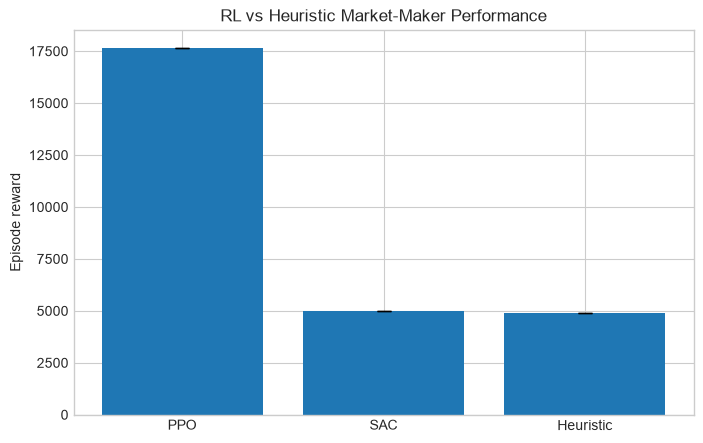

In [7]:
summary = pd.DataFrame(
    [
        {'Agent': 'PPO', 'Mean reward': ppo_mean, 'Std': ppo_std},
        {'Agent': 'SAC', 'Mean reward': sac_mean, 'Std': sac_std},
        {
            'Agent': 'Heuristic',
            'Mean reward': heuristic_summary['mean_reward'],
            'Std': np.std([r.total_reward for r in heuristic_results]),
        },
    ]
)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(summary))
ax.bar(x, summary['Mean reward'], yerr=summary['Std'], capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(summary['Agent'])
ax.set_ylabel('Episode reward')
ax.set_title('RL vs Heuristic Market-Maker Performance')
plt.show()